# Sello 10 — Regresión

### Un modelo que prediga las ventas futuras

**Pregunta de negocio del sello:** ¿Qué variables predicen mejor las unidades vendidas?

Modelo: `unidades ~ precio_unitario + promocion_activa + clima + hora + sucursal`

> Proyecto Final Integrador · TCNT0011 Probabilidad y Estadística I · Café Cordillera
> 
> Método: regresión lineal múltiple (OLS) con statsmodels para coeficientes e inferencia, sklearn para validación en datos no vistos, y Poisson como chequeo de robustez (la variable es un conteo).

## 1. Datos

Cargamos `cafe_cordillera_dataset.csv`. La variable dependiente es `unidades`; los predictores son `precio_unitario`, `promocion_activa`, `clima`, `hora` y `sucursal` (más de los 3 predictores mínimos exigidos).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

for _p in ["cafe_cordillera_dataset.csv", "../cafe_cordillera_dataset.csv"]:
    if os.path.exists(_p):
        DATA_PATH = _p
        break

df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]:,} · Columnas: {df.shape[1]}")
print(df.head(3).to_string(index=False))

Filas: 11,983 · Columnas: 15
 id_transaccion  id_pedido  id_cliente      fecha  hora sucursal producto   categoria  precio_unitario  unidades  medio_pago    clima  promocion_activa promocion_tipo  calificacion_satisfaccion
              1       2033         697 2026-03-02     6  Cartago Limonada bebida_fria             1284         1     tarjeta lluvioso                 0            NaN                        NaN
              2       2033         697 2026-03-02     6  Cartago  Galleta      postre              841         1 sinpe_movil lluvioso                 0            NaN                        NaN
              3       2033         697 2026-03-02     6  Cartago   Frappe bebida_fria             1785         1 sinpe_movil lluvioso                 0            NaN                        NaN


In [2]:
d = df.copy()
d["monto"] = d["precio_unitario"] * d["unidades"]
d = pd.get_dummies(
    d, columns=["clima", "sucursal", "categoria", "medio_pago"],
    drop_first=True, dtype=int,
)
predictores = ["precio_unitario", "promocion_activa", "hora"] + [
    c for c in d.columns
    if c.startswith(("clima_", "sucursal_", "categoria_"))
]
print("Predictores del modelo:")
for p in predictores:
    print(" -", p)
print("\nVariable objetivo `unidades`:")
print(d["unidades"].value_counts().sort_index().to_string())

Predictores del modelo:
 - precio_unitario
 - promocion_activa
 - hora
 - clima_nublado
 - clima_soleado
 - sucursal_Escazu
 - sucursal_Heredia
 - sucursal_San Pedro
 - categoria_bebida_fria
 - categoria_postre
 - categoria_snack

Variable objetivo `unidades`:
unidades
1    8255
2    2470
3    1082
4     176


## 2. Ajuste del modelo (OLS)

Ajustamos el modelo con `statsmodels`. La categoría de referencia de cada variable categórica queda omitida (clima base = `lluvioso`, sucursal base = `Cartago`, categoría base = `bebida_caliente`).

In [3]:
import statsmodels.api as sm

X = sm.add_constant(d[predictores].astype(float))
modelo = sm.OLS(d["unidades"].astype(float), X).fit()
print(modelo.summary().tables[1].as_text())
print(f"R² = {modelo.rsquared:.4f}  ·  R² ajustado = {modelo.rsquared_adj:.4f}")

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.3561      0.041     33.211      0.000       1.276       1.436
precio_unitario       -2.321e-05   2.16e-05     -1.077      0.282   -6.55e-05     1.9e-05
promocion_activa          0.4960      0.013     37.486      0.000       0.470       0.522
hora                     -0.0009      0.001     -0.601      0.548      -0.004       0.002
clima_nublado            -0.0070      0.016     -0.438      0.662      -0.038       0.024
clima_soleado             0.0047      0.016      0.298      0.766      -0.026       0.036
sucursal_Escazu          -0.0378      0.018     -2.066      0.039      -0.074      -0.002
sucursal_Heredia         -0.0157      0.018     -0.894      0.372      -0.050       0.019
sucursal_San Pedro       -0.0137      0.018     -0.776      0.438      -0.048       0.021
categoria_

## 3. ¿Cuál predictor importa más?

Estandarizamos los predictores (media 0, desviación 1) para que los coeficientes sean comparables y poder ordenarlos por importancia.

In [4]:
Xz = (d[predictores] - d[predictores].mean()) / d[predictores].std()
modelo_z = sm.OLS(d["unidades"].astype(float), sm.add_constant(Xz)).fit()
importancia = modelo_z.params.drop("const").sort_values(key=abs, ascending=False)
print("Coeficientes estandarizados (importancia relativa):")
print(importancia.round(4).to_string())

Coeficientes estandarizados (importancia relativa):
promocion_activa         0.2332
categoria_postre        -0.0182
categoria_bebida_fria   -0.0171
sucursal_Escazu         -0.0164
precio_unitario         -0.0083
sucursal_Heredia        -0.0068
sucursal_San Pedro      -0.0059
hora                    -0.0037
clima_nublado           -0.0033
clima_soleado            0.0023
categoria_snack         -0.0013


## 4. Interpretación en lenguaje de negocio

Leemos los coeficientes del modelo original como efectos sobre las **unidades vendidas**.

In [5]:
def interp(nombre, coef, pv):
    sig = "significativo" if pv < 0.05 else "no significativo"
    dir_ = "aumenta" if coef > 0 else "reduce"
    print(f"{nombre}: β = {coef:.4f} (p = {pv:.4f}) → {dir_} las unidades · {sig}")

interp("precio_unitario (por 1 colón)", modelo.params["precio_unitario"],
       modelo.pvalues["precio_unitario"])
interp("promocion_activa (1 vs 0)", modelo.params["promocion_activa"],
       modelo.pvalues["promocion_activa"])
interp("hora", modelo.params["hora"], modelo.pvalues["hora"])
interp("clima_soleado (vs lluvioso)", modelo.params["clima_soleado"],
       modelo.pvalues["clima_soleado"])
interp("categoria_postre (vs bebida_caliente)", modelo.params["categoria_postre"],
       modelo.pvalues["categoria_postre"])
interp("sucursal_Escazu (vs Cartago)", modelo.params["sucursal_Escazu"],
       modelo.pvalues["sucursal_Escazu"])

precio_unitario (por 1 colón): β = -0.0000 (p = 0.2817) → reduce las unidades · no significativo
promocion_activa (1 vs 0): β = 0.4960 (p = 0.0000) → aumenta las unidades · significativo
hora: β = -0.0009 (p = 0.5480) → reduce las unidades · no significativo
clima_soleado (vs lluvioso): β = 0.0047 (p = 0.7658) → aumenta las unidades · no significativo
categoria_postre (vs bebida_caliente): β = -0.0517 (p = 0.0081) → reduce las unidades · significativo
sucursal_Escazu (vs Cartago): β = -0.0378 (p = 0.0388) → reduce las unidades · significativo


## 5. Validación en datos no vistos (sklearn)

Separamos 75 % entrenamiento / 25 % prueba para medir el poder predictivo real.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_ = d[predictores].to_numpy()
y_ = d["unidades"].to_numpy()
Xt, Xv, yt, yv = train_test_split(X_, y_, test_size=0.25, random_state=42)
lr = LinearRegression().fit(Xt, yt)
print(f"R² entrenamiento = {r2_score(yt, lr.predict(Xt)):.4f}")
print(f"R² validación    = {r2_score(yv, lr.predict(Xv)):.4f}")

R² entrenamiento = 0.1101
R² validación    = 0.1009


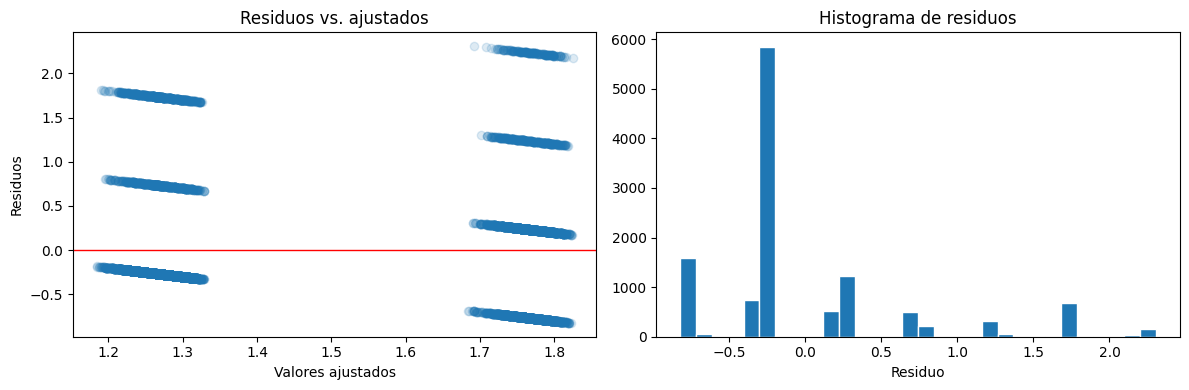

In [7]:
res = modelo.resid
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(modelo.fittedvalues, res, alpha=0.15)
ax[0].axhline(0, color="red", lw=1)
ax[0].set_xlabel("Valores ajustados")
ax[0].set_ylabel("Residuos")
ax[0].set_title("Residuos vs. ajustados")
ax[1].hist(res, bins=30, edgecolor="white")
ax[1].set_xlabel("Residuo")
ax[1].set_title("Histograma de residuos")
plt.tight_layout()
plt.show()

## 6. Robustez: `unidades` es un conteo

La variable dependiente toma valores 1–4. Como chequeo, ajustamos una regresión **Poisson** (adecuada para conteos) y comparamos los coeficientes.

In [8]:
from statsmodels.discrete.count_model import Poisson

Xp = sm.add_constant(d[predictores].astype(float))
pois = Poisson(d["unidades"].astype(int), Xp).fit(disp=0)
print(f"Pseudo-R² (McFadden) = {pois.prsquared:.4f}")
print(pois.params.round(4).to_string())

Pseudo-R² (McFadden) = 0.0148
const                    0.2995
precio_unitario         -0.0000
promocion_activa         0.3302
hora                    -0.0006
clima_nublado           -0.0056
clima_soleado            0.0027
sucursal_Escazu         -0.0269
sucursal_Heredia        -0.0109
sucursal_San Pedro      -0.0094
categoria_bebida_fria   -0.0239
categoria_postre        -0.0362
categoria_snack         -0.0034


## 7. Conclusión (lenguaje de negocio)

El modelo explica cerca del **11 %** de la variabilidad de las unidades (R² ≈ 0.11, similar en validación), por lo que sirve como punto de partida, no como predicción exacta. **La promoción activa es el predictor más fuerte**: tener promoción activa añade ≈ **0.5 unidades** por transacción (p < 0.001). El precio y el clima tienen efectos despreciables y no significativos sobre la cantidad vendida; la hora tampoco pesa. La categoría y la sucursal aportan diferencias pequeñas (postre ≈ −0.05 unidades vs. bebida caliente; Escazú ≈ −0.04 vs. Cartago). **Recomendación de negocio:** si la meta es vender más unidades, la palanca efectiva es la promoción, no bajar precios ni responder al clima; para decisiones de pronóstico, incorporar variables como demanda histórica y día de la semana.